# Polymarket Data Exploration

Exploring the legacy market data migrated from SQLite to JSONL.

**Data source:** `data/legacy_candles.jsonl` — 869 candles with ~94K nested snapshots.

Each line is a **CandleRecord** (5-min BTC up/down candle) with its **Snapshots** (per-second market observations) nested inside.

| Field | Description |
|-------|-------------|
| `candle_id` | Slug identifier (e.g. `btc-updown-5m-1772025300`) |
| `open/high/low/close` | BTC OHLC for the 5-min window |
| `outcome` | `UP` or `DOWN` (close >= open) |
| `final_ret` | Log return: ln(close/open) |
| `snapshots[]` | Per-second observations with BTC price, orderbook levels, elapsed % |

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

## 1. Load the Data

In [2]:
DATA_PATH = Path("../data/legacy_candles.jsonl")

candles = []
with open(DATA_PATH) as f:
    for line in f:
        candles.append(json.loads(line))

print(f"Loaded {len(candles)} candles")
print(f"Total snapshots: {sum(len(c['snapshots']) for c in candles):,}")

Loaded 869 candles
Total snapshots: 94,336


In [3]:
# Inspect first candle structure
sample = candles[0]
{k: v if k != "snapshots" else f"[{len(v)} snapshots]" for k, v in sample.items()}

{'candle_id': 'btc-updown-5m-1772025300',
 'start_time': 1772025300.0,
 'end_time': 1772025600.0,
 'open': 66092.75,
 'high': 66094.55,
 'low': 66092.75,
 'close': 66094.55,
 'volume': 0.0,
 'outcome': 'UP',
 'final_ret': 2.723408376025444e-05,
 'snapshots': '[30 snapshots]'}

In [4]:
# Inspect a single snapshot
candles[0]["snapshots"][0]

{'timestamp': 1772025515.626037,
 'tick_timestamp': 1772025515.626037,
 'elapsed_pct': 0.712961,
 'btc_price': 66092.75,
 'btc_bid': 66092.75,
 'btc_ask': 66092.75,
 'up_bids': [[0.84, 5670.5104]],
 'up_asks': [[0.85, 21193.359]],
 'down_bids': [[0.15, 601.7915]],
 'down_asks': [[0.16, 25673.9771]],
 'up_last_trade': None,
 'down_last_trade': None,
 'market_volume': 53139.638}

## 2. Candle-Level Distributions

In [5]:
outcomes = [c["outcome"] for c in candles]
returns = [c["final_ret"] for c in candles]
opens = [c["open"] for c in candles]
closes = [c["close"] for c in candles]
snap_counts = [len(c["snapshots"]) for c in candles]

print(f"Candles: {len(candles)}")
print(f"UP: {outcomes.count('UP')} ({outcomes.count('UP') / len(candles) * 100:.1f}%)")
print(f"DOWN: {outcomes.count('DOWN')} ({outcomes.count('DOWN') / len(candles) * 100:.1f}%)")
print(f"BTC range: ${min(opens):,.2f} - ${max(closes):,.2f}")
print(f"Snapshots per candle: {np.mean(snap_counts):.0f} avg, {min(snap_counts)}-{max(snap_counts)} range")

Candles: 869
UP: 426 (49.0%)
DOWN: 443 (51.0%)
BTC range: $63,899.28 - $69,442.45
Snapshots per candle: 109 avg, 7-219 range


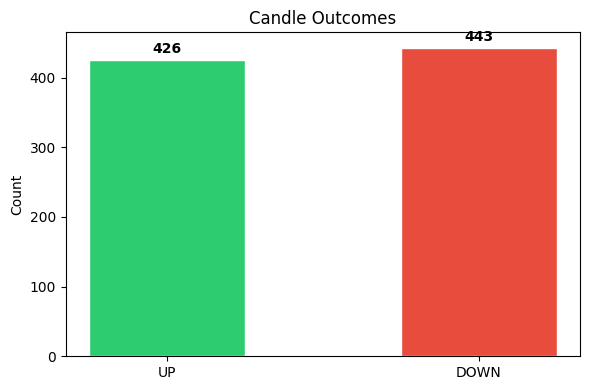

In [6]:
# Outcome distribution
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["UP", "DOWN"]
counts = [outcomes.count("UP"), outcomes.count("DOWN")]
colors = ["#2ecc71", "#e74c3c"]
bars = ax.bar(labels, counts, color=colors, edgecolor="white", width=0.5)
for bar, count in zip(bars, counts, strict=False):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, str(count), ha="center", va="bottom", fontweight="bold"
    )
ax.set_title("Candle Outcomes")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

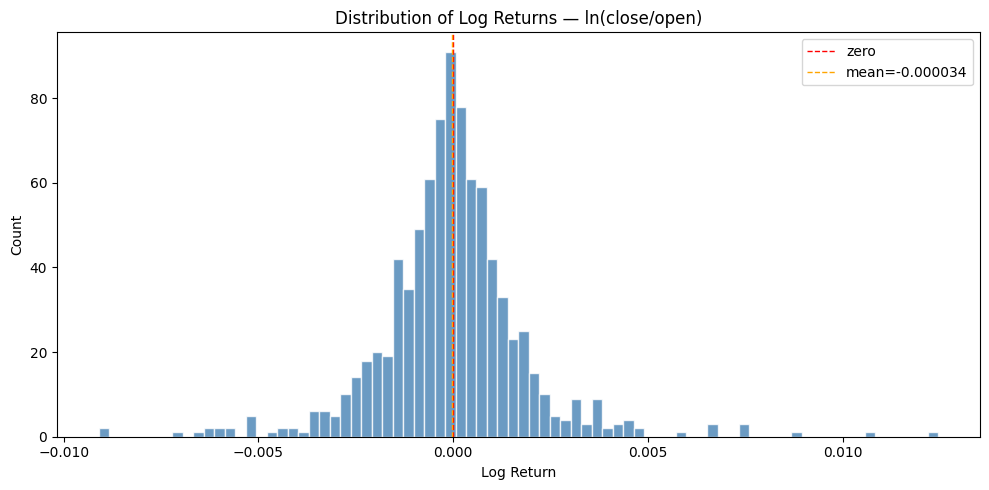

In [7]:
# Log returns distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(returns, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(0, color="red", linestyle="--", linewidth=1, label="zero")
ax.axvline(np.mean(returns), color="orange", linestyle="--", linewidth=1, label=f"mean={np.mean(returns):.6f}")
ax.set_title("Distribution of Log Returns — ln(close/open)")
ax.set_xlabel("Log Return")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

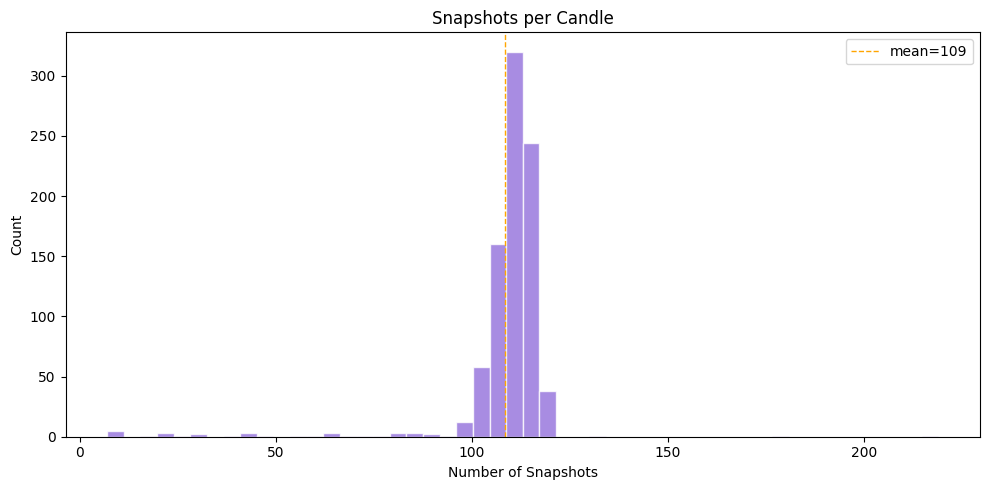

In [8]:
# Snapshots per candle distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(snap_counts, bins=50, color="mediumpurple", edgecolor="white", alpha=0.8)
ax.axvline(np.mean(snap_counts), color="orange", linestyle="--", linewidth=1, label=f"mean={np.mean(snap_counts):.0f}")
ax.set_title("Snapshots per Candle")
ax.set_xlabel("Number of Snapshots")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

## 3. BTC Price Over Time

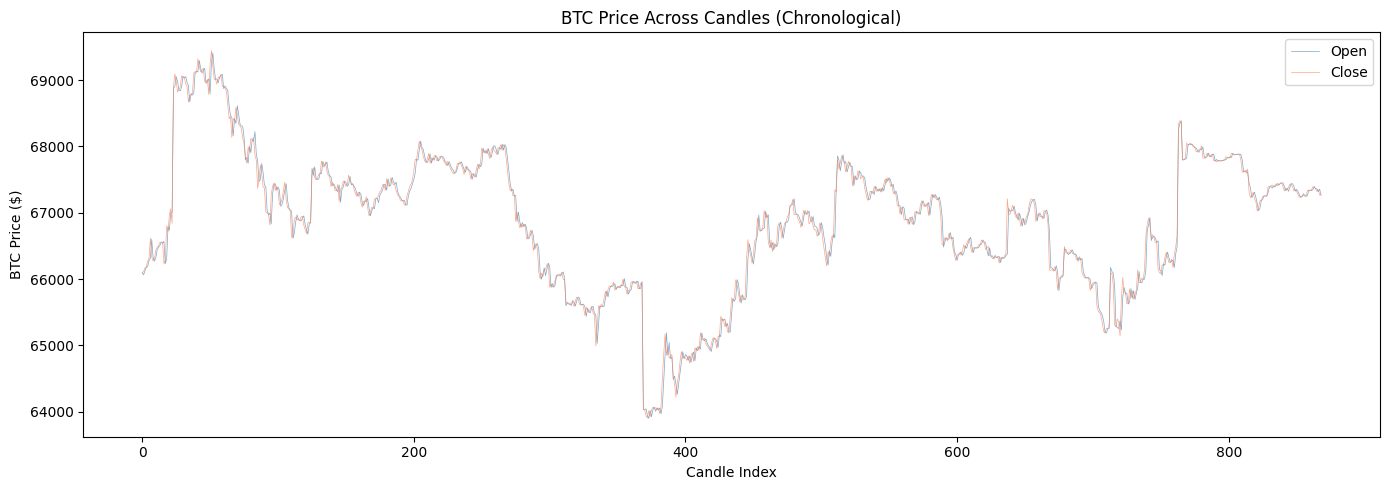

In [9]:
# BTC open price per candle (chronological)
sorted_candles = sorted(candles, key=lambda c: c["start_time"])
times = [c["start_time"] for c in sorted_candles]
btc_opens = [c["open"] for c in sorted_candles]
btc_closes = [c["close"] for c in sorted_candles]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(btc_opens)), btc_opens, linewidth=0.5, color="steelblue", alpha=0.7, label="Open")
ax.plot(range(len(btc_closes)), btc_closes, linewidth=0.5, color="coral", alpha=0.7, label="Close")
ax.set_title("BTC Price Across Candles (Chronological)")
ax.set_xlabel("Candle Index")
ax.set_ylabel("BTC Price ($)")
ax.legend()
plt.tight_layout()
plt.show()

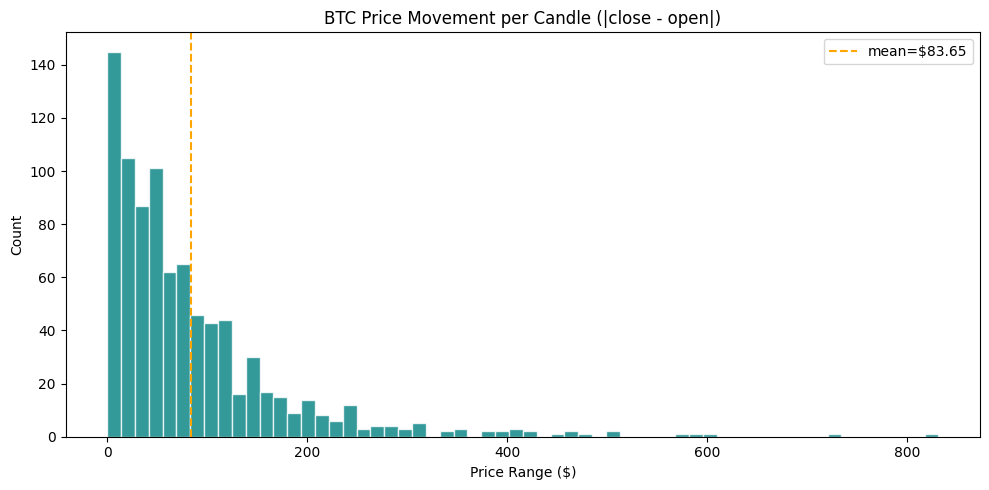

In [10]:
# BTC price range (high - low) per candle
price_ranges = [c["high"] - c["low"] for c in sorted_candles]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(price_ranges, bins=60, color="teal", edgecolor="white", alpha=0.8)
ax.axvline(np.mean(price_ranges), color="orange", linestyle="--", label=f"mean=${np.mean(price_ranges):.2f}")
ax.set_title("BTC Price Movement per Candle (|close - open|)")
ax.set_xlabel("Price Range ($)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Snapshot-Level Analysis

In [11]:
# Flatten all snapshots for analysis
all_snaps = []
for c in candles:
    for s in c["snapshots"]:
        s["_outcome"] = c["outcome"]
        all_snaps.append(s)

print(f"Total snapshots: {len(all_snaps):,}")

Total snapshots: 94,336


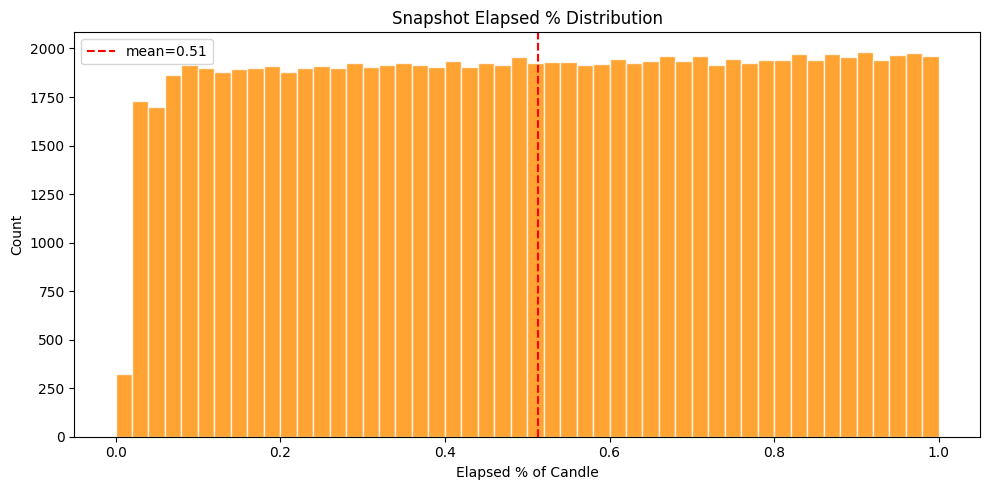

In [12]:
# Elapsed percentage distribution — when do snapshots start?
elapsed = [s["elapsed_pct"] for s in all_snaps]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(elapsed, bins=50, color="darkorange", edgecolor="white", alpha=0.8)
ax.set_title("Snapshot Elapsed % Distribution")
ax.set_xlabel("Elapsed % of Candle")
ax.set_ylabel("Count")
ax.axvline(np.mean(elapsed), color="red", linestyle="--", label=f"mean={np.mean(elapsed):.2f}")
ax.legend()
plt.tight_layout()
plt.show()

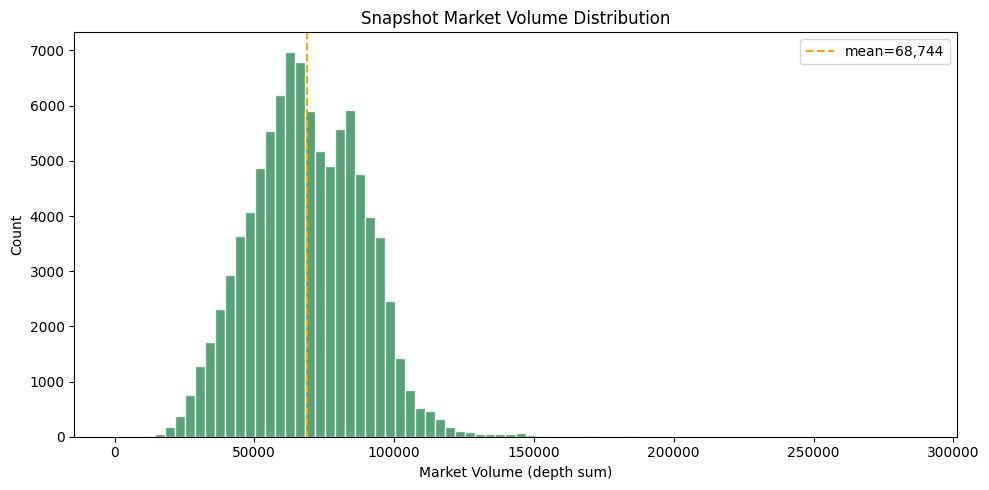

In [13]:
# Market volume distribution
volumes = [s["market_volume"] for s in all_snaps]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(volumes, bins=80, color="seagreen", edgecolor="white", alpha=0.8)
ax.axvline(np.mean(volumes), color="orange", linestyle="--", label=f"mean={np.mean(volumes):,.0f}")
ax.set_title("Snapshot Market Volume Distribution")
ax.set_xlabel("Market Volume (depth sum)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Orderbook Analysis

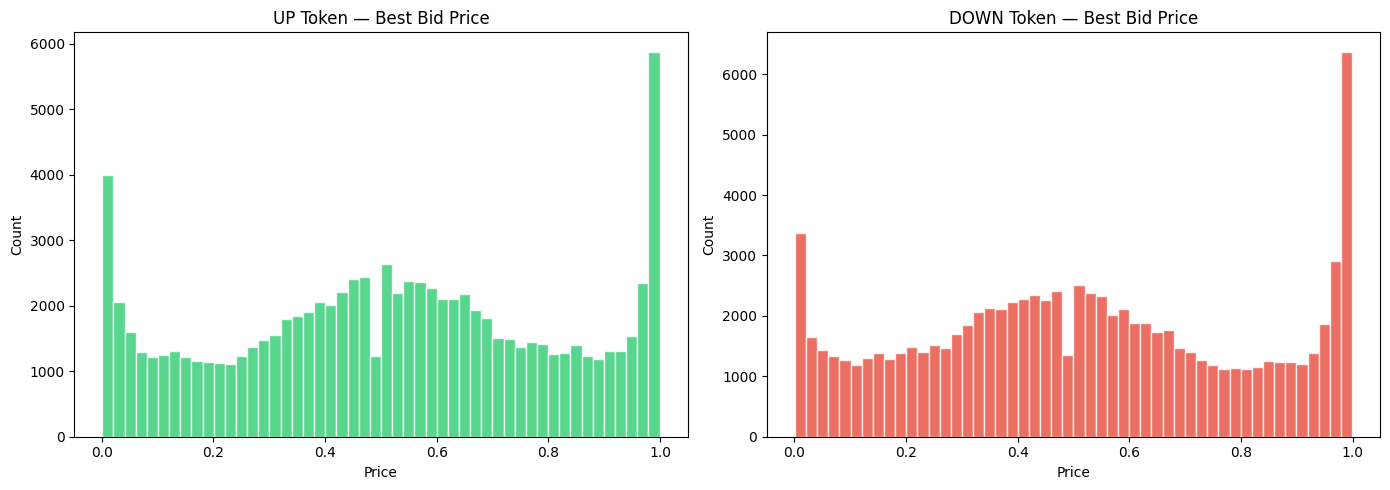

In [14]:
# UP token best bid distribution
up_bids = [s["up_bids"][0][0] for s in all_snaps if s["up_bids"]]
down_bids = [s["down_bids"][0][0] for s in all_snaps if s["down_bids"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(up_bids, bins=50, color="#2ecc71", edgecolor="white", alpha=0.8)
axes[0].set_title("UP Token — Best Bid Price")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Count")

axes[1].hist(down_bids, bins=50, color="#e74c3c", edgecolor="white", alpha=0.8)
axes[1].set_title("DOWN Token — Best Bid Price")
axes[1].set_xlabel("Price")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

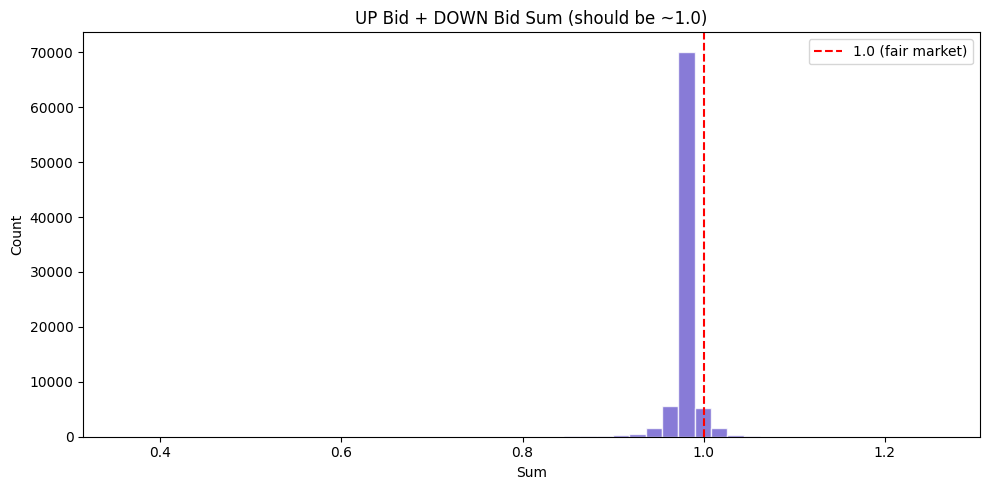

In [15]:
# UP bid + DOWN bid should sum to ~1.0 (complementary market)
paired = [(s["up_bids"][0][0], s["down_bids"][0][0]) for s in all_snaps if s["up_bids"] and s["down_bids"]]
sums = [u + d for u, d in paired]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sums, bins=50, color="slateblue", edgecolor="white", alpha=0.8)
ax.axvline(1.0, color="red", linestyle="--", label="1.0 (fair market)")
ax.set_title("UP Bid + DOWN Bid Sum (should be ~1.0)")
ax.set_xlabel("Sum")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Scatter Plots — Correlations

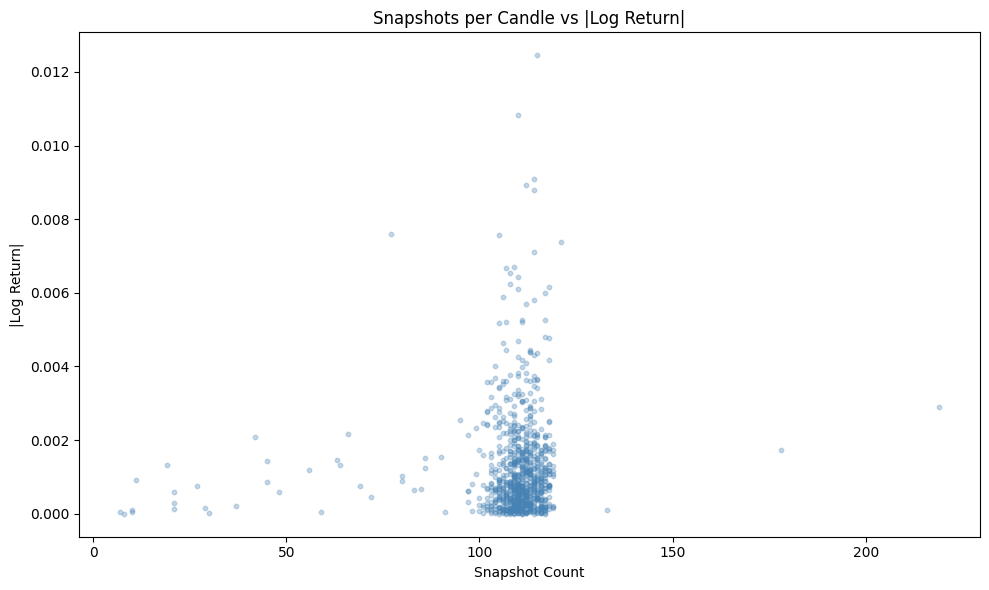

In [16]:
# Snapshots per candle vs absolute return
abs_returns = [abs(c["final_ret"]) for c in candles]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(snap_counts, abs_returns, alpha=0.3, s=10, color="steelblue")
ax.set_title("Snapshots per Candle vs |Log Return|")
ax.set_xlabel("Snapshot Count")
ax.set_ylabel("|Log Return|")
plt.tight_layout()
plt.show()

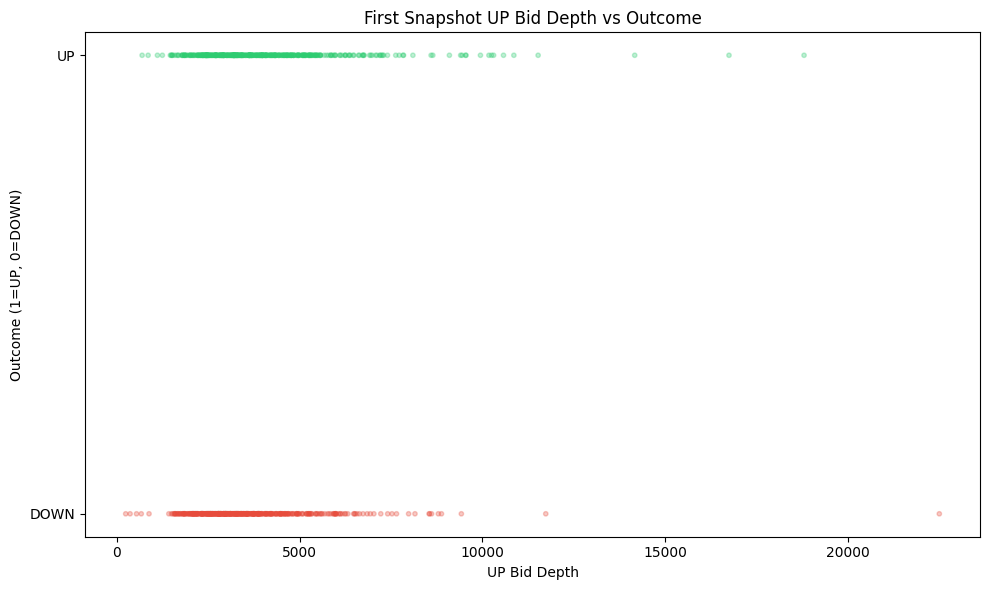

In [17]:
# UP bid depth vs outcome — are deeper books predictive?
# Take the first snapshot of each candle as the "entry" observation
entry_up_depth = []
entry_outcomes = []
for c in candles:
    if c["snapshots"] and c["snapshots"][0]["up_bids"]:
        entry_up_depth.append(c["snapshots"][0]["up_bids"][0][1])
        entry_outcomes.append(1 if c["outcome"] == "UP" else 0)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2ecc71" if o == 1 else "#e74c3c" for o in entry_outcomes]
ax.scatter(entry_up_depth, entry_outcomes, alpha=0.3, s=10, c=colors)
ax.set_title("First Snapshot UP Bid Depth vs Outcome")
ax.set_xlabel("UP Bid Depth")
ax.set_ylabel("Outcome (1=UP, 0=DOWN)")
ax.set_yticks([0, 1])
ax.set_yticklabels(["DOWN", "UP"])
plt.tight_layout()
plt.show()

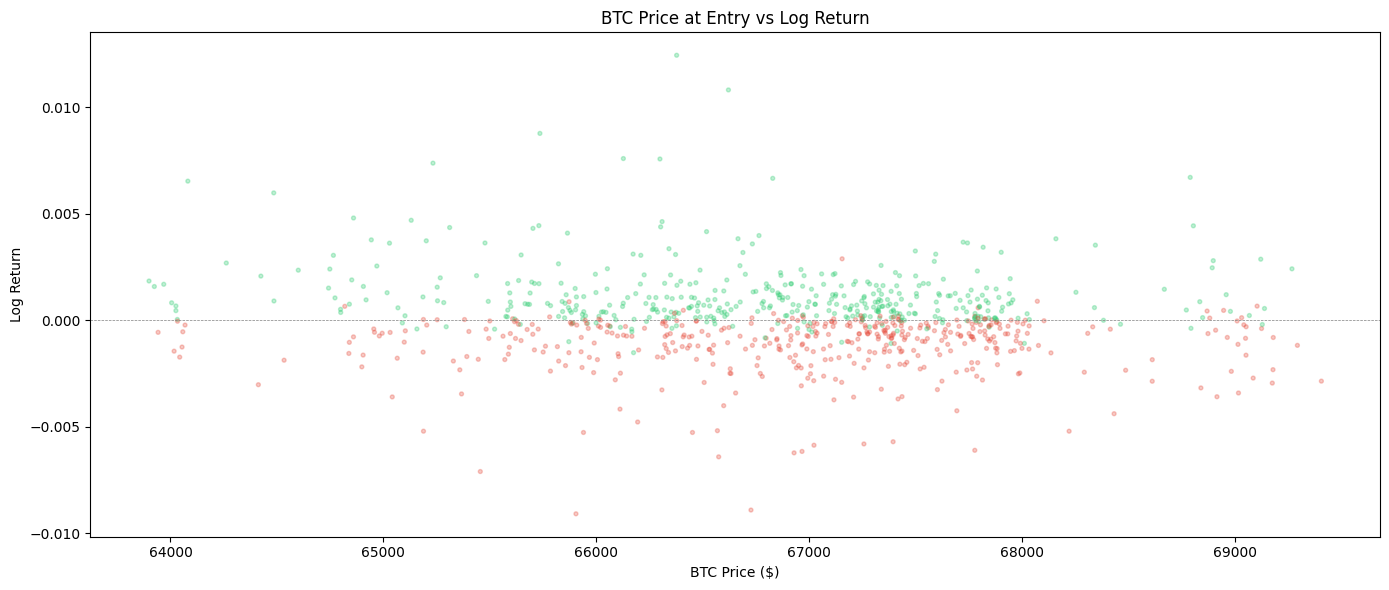

In [18]:
# BTC price at first snapshot vs log return (colored by outcome)
entry_btc = []
entry_ret = []
entry_out = []
for c in candles:
    if c["snapshots"]:
        entry_btc.append(c["snapshots"][0]["btc_price"])
        entry_ret.append(c["final_ret"])
        entry_out.append(c["outcome"])

fig, ax = plt.subplots(figsize=(14, 6))
colors = ["#2ecc71" if o == "UP" else "#e74c3c" for o in entry_out]
ax.scatter(entry_btc, entry_ret, alpha=0.3, s=8, c=colors)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
ax.set_title("BTC Price at Entry vs Log Return")
ax.set_xlabel("BTC Price ($)")
ax.set_ylabel("Log Return")
plt.tight_layout()
plt.show()

## 7. Intra-Candle Dynamics

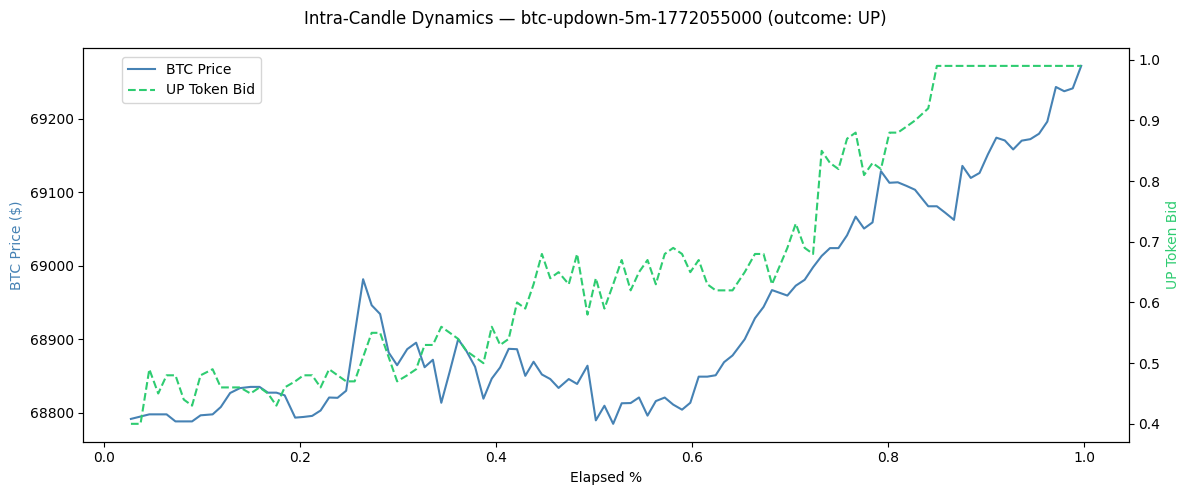

In [19]:
# Pick a sample candle and plot its intra-candle BTC price evolution
sample_idx = 50
sc = sorted_candles[sample_idx]
snaps = sc["snapshots"]

if snaps:
    snap_elapsed = [s["elapsed_pct"] for s in snaps]
    snap_btc = [s["btc_price"] for s in snaps]
    snap_up_bid = [s["up_bids"][0][0] if s["up_bids"] else None for s in snaps]

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(snap_elapsed, snap_btc, color="steelblue", linewidth=1.5, label="BTC Price")
    ax1.set_xlabel("Elapsed %")
    ax1.set_ylabel("BTC Price ($)", color="steelblue")

    ax2 = ax1.twinx()
    valid = [(e, b) for e, b in zip(snap_elapsed, snap_up_bid, strict=False) if b is not None]
    if valid:
        ax2.plot(
            [v[0] for v in valid],
            [v[1] for v in valid],
            color="#2ecc71",
            linewidth=1.5,
            linestyle="--",
            label="UP Token Bid",
        )
        ax2.set_ylabel("UP Token Bid", color="#2ecc71")

    fig.suptitle(f"Intra-Candle Dynamics — {sc['candle_id']} (outcome: {sc['outcome']})")
    fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
    plt.tight_layout()
    plt.show()
else:
    print(f"Candle {sample_idx} has no snapshots")

In [ ]:
# Average UP token bid trajectory by outcome
# Bin snapshots into 20 elapsed-% buckets, average UP bid per bucket
n_bins = 20
up_trajectory = {"UP": [[] for _ in range(n_bins)], "DOWN": [[] for _ in range(n_bins)]}

for c in candles:
    outcome = c["outcome"]
    for s in c["snapshots"]:
        if s["up_bids"]:
            bucket = min(int(s["elapsed_pct"] * n_bins), n_bins - 1)
            up_trajectory[outcome][bucket].append(s["up_bids"][0][0])

x = np.linspace(0, 1, n_bins)
fig, ax = plt.subplots(figsize=(12, 5))
for outcome, color, label in [("UP", "#2ecc71", "UP candles"), ("DOWN", "#e74c3c", "DOWN candles")]:
    means = [np.mean(bucket) if bucket else np.nan for bucket in up_trajectory[outcome]]
    ax.plot(x, means, color=color, linewidth=2, label=label, marker="o", markersize=4)

ax.set_title("Average UP Token Bid Trajectory by Outcome")
ax.set_xlabel("Elapsed % of Candle")
ax.set_ylabel("UP Token Best Bid")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Data Quality Summary

In [20]:
# Summary stats
empty_books = sum(1 for s in all_snaps if not s["up_bids"] or not s["down_bids"])
no_snap_candles = sum(1 for c in candles if not c["snapshots"])

print("=== Data Quality ===")
print(f"Candles:               {len(candles)}")
print(f"  with no snapshots:   {no_snap_candles}")
print(f"  UP outcome:          {outcomes.count('UP')}")
print(f"  DOWN outcome:        {outcomes.count('DOWN')}")
print()
print(f"Snapshots:             {len(all_snaps):,}")
print(f"  empty orderbook:     {empty_books:,} ({empty_books / len(all_snaps) * 100:.1f}%)")
print(f"  avg per candle:      {np.mean(snap_counts):.1f}")
print(f"  median per candle:   {np.median(snap_counts):.0f}")
print()
print(f"BTC Price Range:       ${min(opens):,.2f} - ${max(closes):,.2f}")
print(f"Mean |log return|:     {np.mean(np.abs(returns)):.6f}")
print(f"Std log return:        {np.std(returns):.6f}")
print()
print("=== Degraded Fields (legacy limitations) ===")
print("  btc_bid/btc_ask:     set to btc_price (no BTC spread in legacy)")
print("  tick_timestamp:      same as timestamp")
print("  up/down_last_trade:  always null")
print("  orderbook:           1 level only (best bid/ask + depth)")
print("  candle high/low:     max/min of open,close (no intra-candle data)")
print("  volume:              0.0 (not tracked in legacy)")

=== Data Quality ===
Candles:               869
  with no snapshots:   0
  UP outcome:          426
  DOWN outcome:        443

Snapshots:             94,336
  empty orderbook:     8,582 (9.1%)
  avg per candle:      108.6
  median per candle:   111

BTC Price Range:       $63,899.28 - $69,442.45
Mean |log return|:     0.001253
Std log return:        0.001887

=== Degraded Fields (legacy limitations) ===
  btc_bid/btc_ask:     set to btc_price (no BTC spread in legacy)
  tick_timestamp:      same as timestamp
  up/down_last_trade:  always null
  orderbook:           1 level only (best bid/ask + depth)
  candle high/low:     max/min of open,close (no intra-candle data)
  volume:              0.0 (not tracked in legacy)
